In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [2]:
import torch 
from src.config import CHECKPOINT_DIR
import matplotlib.pyplot as plt

In [3]:
checkpoint_path = CHECKPOINT_DIR / "baseline_cnn_SepConvLSTM" / "v1" / "best_model.pt"
checkpoint = torch.load(checkpoint_path, map_location=torch.device('cpu'))

In [5]:
checkpoint_path = CHECKPOINT_DIR / "baseline_cnn_lstm" / "baseline_cnn_lstm_v1.pt"
checkpoint = torch.load(checkpoint_path)

In [4]:
print(checkpoint["config"])

{'num_frames': 32, 'batch_size': 4, 'epochs': 50, 'augment': True, 'freeze_cnn': True, 'partial_freeze_cnn': False, 'early_stopping_patience': 10, 'scheduler_patience': 3, 'hidden_channels': 128, 'learning_rate': 2e-05, 'dropout': 0.4, 'reduced_channels': 64}


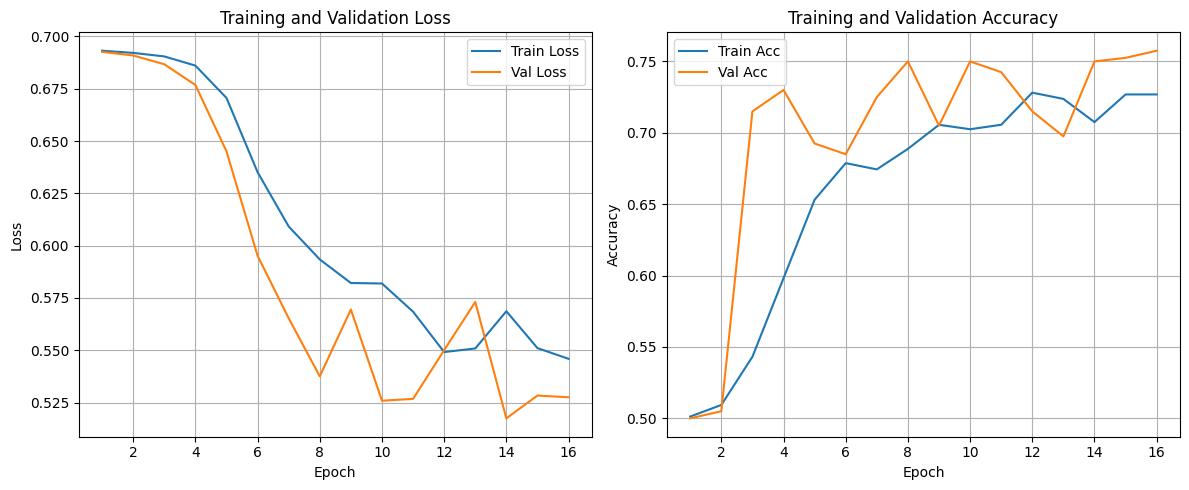

In [5]:
history = checkpoint["history"]
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [6]:
history["train_acc"][-1], history["val_acc"][-1]

(0.726875, 0.7575)

In [7]:
print("final training accuracy:", history["train_acc"][-1])
print("final validation accuracy:", history["val_acc"][-1])
print("\nfinal training loss:", history["train_loss"][-1])
print("final validation loss:", history["val_loss"][-1])

final training accuracy: 0.726875
final validation accuracy: 0.7575

final training loss: 0.5458901397883892
final validation loss: 0.5275141714513302


In [10]:
from src.baseline_cnn_lstm_2 import BaselineCNNLSTM2
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model = BaselineCNNLSTM2(
    hidden_channels=64,
    reduced_channels=64,
    cnn_cutoff=16,
    dropout=0.5,
    freeze_cnn=True
).to(device)

In [11]:
from torch.utils.data import DataLoader
from src.rwf2000 import RWF2000Dataset
from src.config import DATASET_ROOT


train_dataset = RWF2000Dataset(DATASET_ROOT, split="train", num_frames=16, augment=True)
train_loader = DataLoader(
        train_dataset,
        batch_size=4,
        shuffle=True,
        num_workers=4
    )

videos, labels = next(iter(train_loader))
videos = videos.to(device)

outputs = model(videos)

print(videos.shape)
print(outputs.shape)

torch.Size([4, 16, 3, 224, 224])
torch.Size([4, 2])
